<h1>Preprocessing and Data Analysis</h1>

<h3>Importing libraries</h3>

In [7]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<h3>Validating Dataset Parsing and Feature Integrity</h3>

In [2]:
# Define paths relative to the notebook folder
input_path = "../data/crime_dc.csv"
output_path = "../data/crime_clean.csv"

# STEP 1: Load the raw CSV correctly (handles commas inside quotes)
df = pd.read_csv(input_path, quoting=1)

# STEP 2: Preview the first few rows to verify correct parsing
print("✅ Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nFirst few rows:")
display(df.head())

# STEP 3: Save the cleaned version back into the data folder
df.to_csv(output_path, index=False)
print(f"\n✅ Cleaned dataset saved to '{output_path}'")

✅ Dataset loaded successfully!
Number of rows: 26091
Number of columns: 28

First few rows:


,neighborhood_cluster,offense_group,census_tract,longitude,end_date,offense_text,shift,district,yblock,ward,...,xblock,block,start_date,ccn,offense,anc,report_date,method,location,latitude
0,cluster 38,violent,7404.0,-76.976591,NaN,HOMICIDE,midnight,7.0,131428.00,8.0,...,402032.00,1800 - 1824 block of frederick douglass place se,2023-02-23 16:24:00,23029603,HOMICIDE,8C,2023-02-24 00:00:00,gun,"38.8506559459,-76.9765909045",38.850656
1,cluster 20,violent,9504.0,-76.993575,2023-06-16 18:53:00,ASSAULT W/DANGEROUS WEAPON,day,4.0,140787.56,5.0,...,400557.06,900 - 998 block of michigan avenue ne,2023-06-16 18:29:00,23096959,ASSAULT W/DANGEROUS WEAPON,5B,2023-06-17 11:16:47,others,"38.934972488,-76.9935749549",38.934972
2,cluster 25,property,8410.0,-76.990893,2023-04-13 13:00:00,THEFT/OTHER,midnight,1.0,136927.00,6.0,...,400790.00,1100 - 1199 block of h street ne,2023-04-12 19:30:00,23058339,THEFT/OTHER,6A,2023-04-15 03:15:41,others,"38.900195113,-76.9908927027",38.900195
3,cluster 1,property,3801.0,-77.040824,2023-08-20 22:02:00,THEFT/OTHER,evening,3.0,138822.23,1.0,...,396459.65,1731 - 1785 block of florida avenue nw,2023-08-20 21:10:00,23137253,THEFT/OTHER,1C,2023-08-26 21:56:04,others,"38.9172612211,-77.0408237172",38.917261
4,cluster 6,property,10700.0,-77.040859,2023-05-20 15:54:00,THEFT/OTHER,evening,2.0,137483.00,2.0,...,396456.00,1130 - 1199 block of connecticut avenue nw,2023-05-20 15:40:00,23079620,THEFT/OTHER,2C,2023-05-20 19:48:30,others,"38.9051969682,-77.0408588935",38.905197



✅ Cleaned dataset saved to '../data/crime_clean.csv'


<h2>Data Analysis</h2>

<h3>Dataset Information</h3>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26091 entries, 0 to 26090
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   neighborhood_cluster  26091 non-null  object 
 1   offense_group         26091 non-null  object 
 2   census_tract          26080 non-null  float64
 3   longitude             26091 non-null  float64
 4   end_date              24003 non-null  object 
 5   offense_text          26091 non-null  object 
 6   shift                 26091 non-null  object 
 7   district              26091 non-null  float64
 8   yblock                26091 non-null  float64
 9   ward                  26089 non-null  float64
 10  year                  26091 non-null  int64  
 11  offensekey            26091 non-null  object 
 12  bid                   4668 non-null   object 
 13  sector                25946 non-null  object 
 14  psa                   25946 non-null  float64
 15  ucr_rank           

<h3>Identifying Missing Values</h3>

In [4]:
# Check for null values
df.isnull().sum()

neighborhood_cluster        0
offense_group               0
census_tract               11
longitude                   0
end_date                 2088
offense_text                0
shift                       0
district                    0
yblock                      0
ward                        2
year                        0
offensekey                  0
bid                     21423
sector                    145
psa                       145
ucr_rank                    0
block_group                11
voting_precinct             3
xblock                      0
block                       0
start_date                  2
ccn                         0
offense                     0
anc                         2
report_date                 0
method                      0
location                    0
latitude                    0
dtype: int64

<h3>Some random visualisations (to explore the trends)</h3>

<Figure size 1200x1500 with 0 Axes>

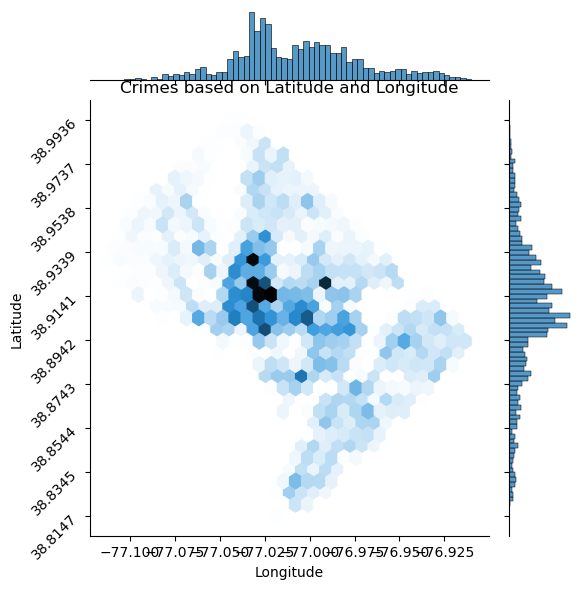

In [10]:
plt.figure(figsize=(12, 15))
ax = sns.jointplot(x=df['longitude'], y=df['latitude'], kind='hex', gridsize=30)
ax.ax_marg_y.set_yticks(np.linspace(min(df['latitude']), max(df['latitude']), 10))  
plt.tight_layout()
plt.title("Crimes based on Latitude and Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.yticks(rotation=45)
plt.show()

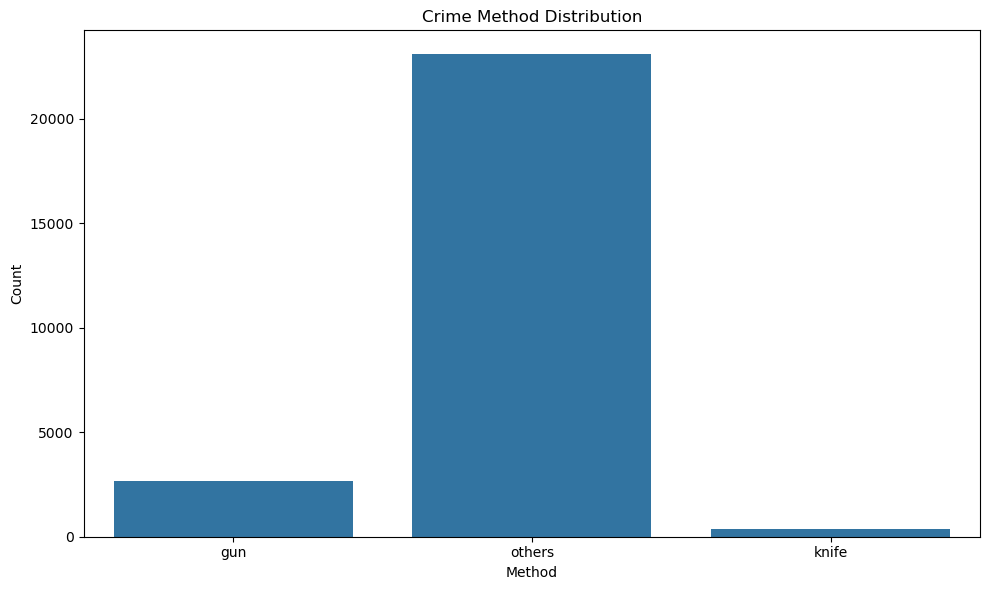

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='method')
plt.title('Crime Method Distribution')
plt.xlabel('Method')
plt.ylabel('Count')
plt.tight_layout()

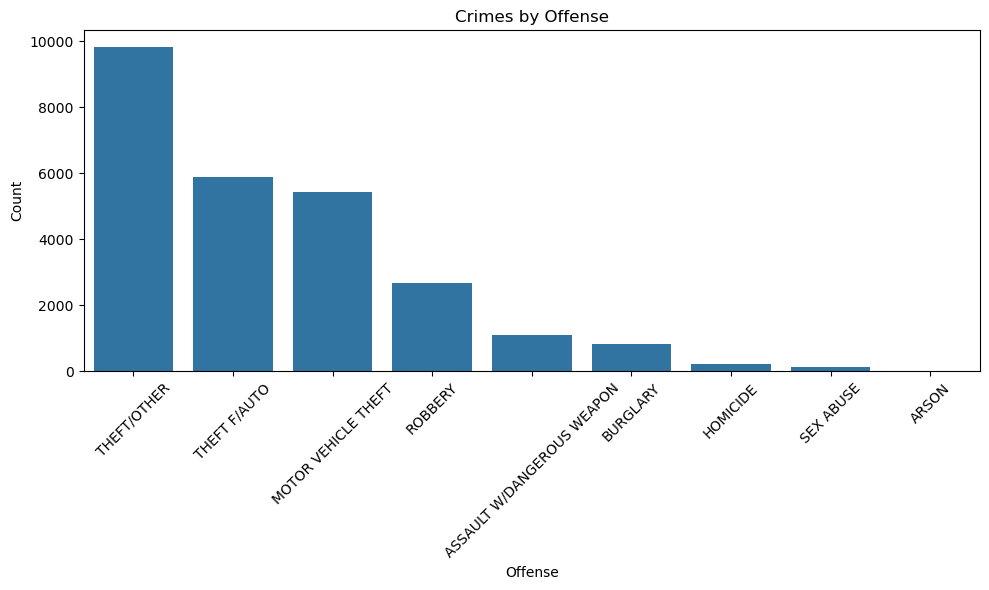

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='offense', order=df['offense'].value_counts().index)
plt.title('Crimes by Offense')
plt.xlabel('Offense')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

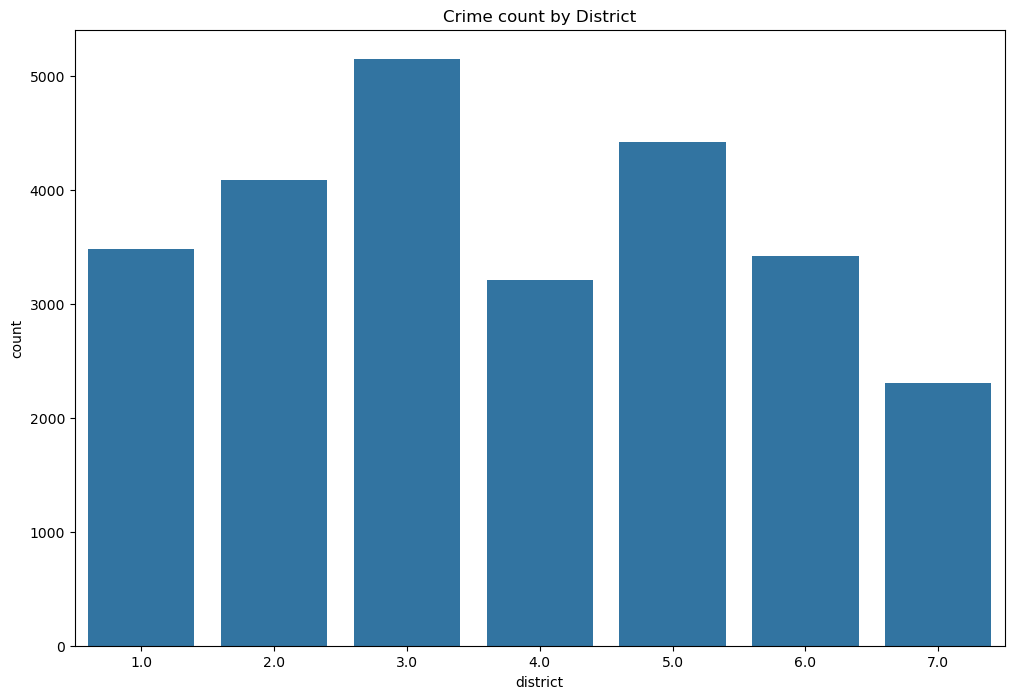

In [13]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='district')
plt.title("Crime count by District")
plt.show()

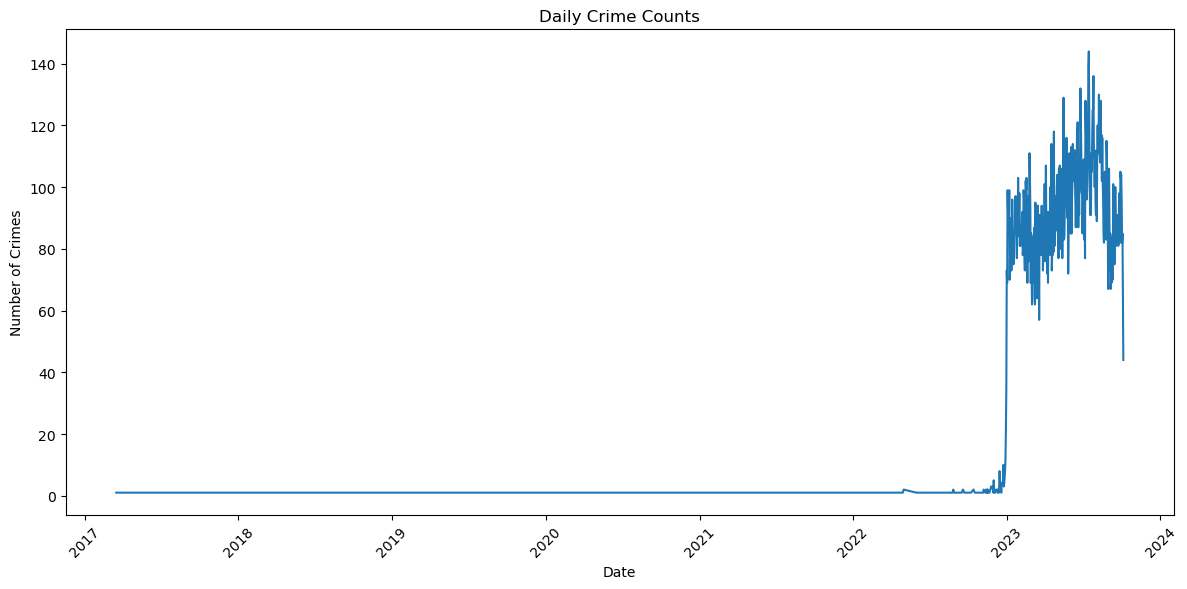

In [14]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

daily_counts = df['start_date'].dt.date.value_counts().sort_index()
weekly_counts = df['start_date'].dt.to_period('W').value_counts().sort_index()
monthly_counts = df['start_date'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.lineplot(x=daily_counts.index, y=daily_counts.values)
plt.title('Daily Crime Counts')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

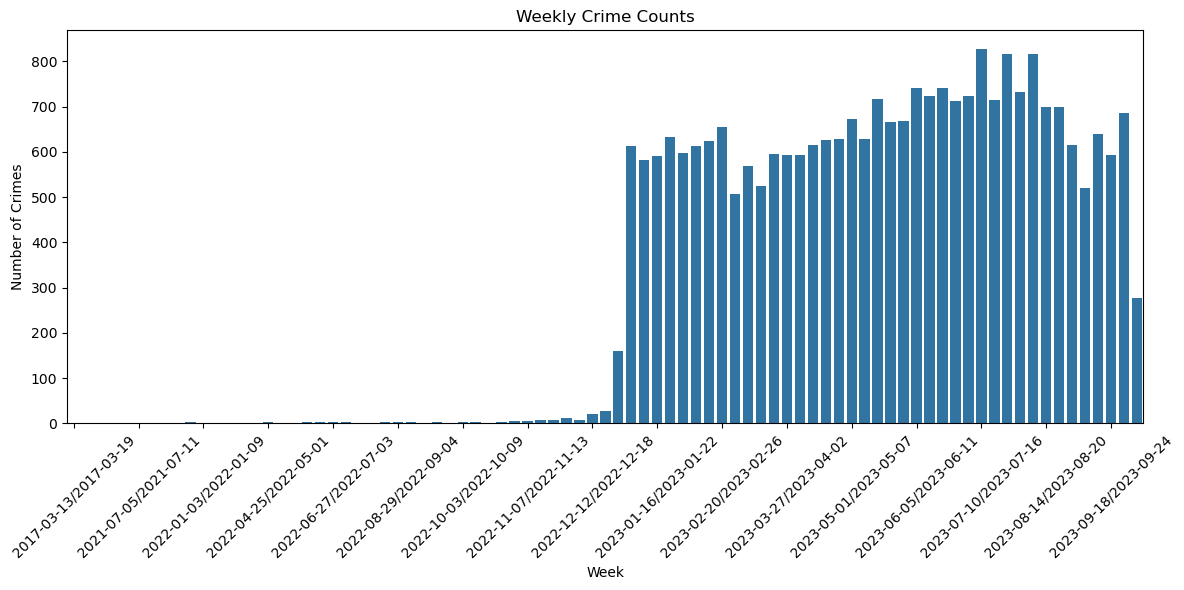

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(x=weekly_counts.index.astype(str), y=weekly_counts.values)
locs, labels = plt.xticks()
plt.xticks(locs[::5], weekly_counts.index.astype(str)[::5], rotation=45)

plt.title('Weekly Crime Counts')
plt.xlabel('Week')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.show()

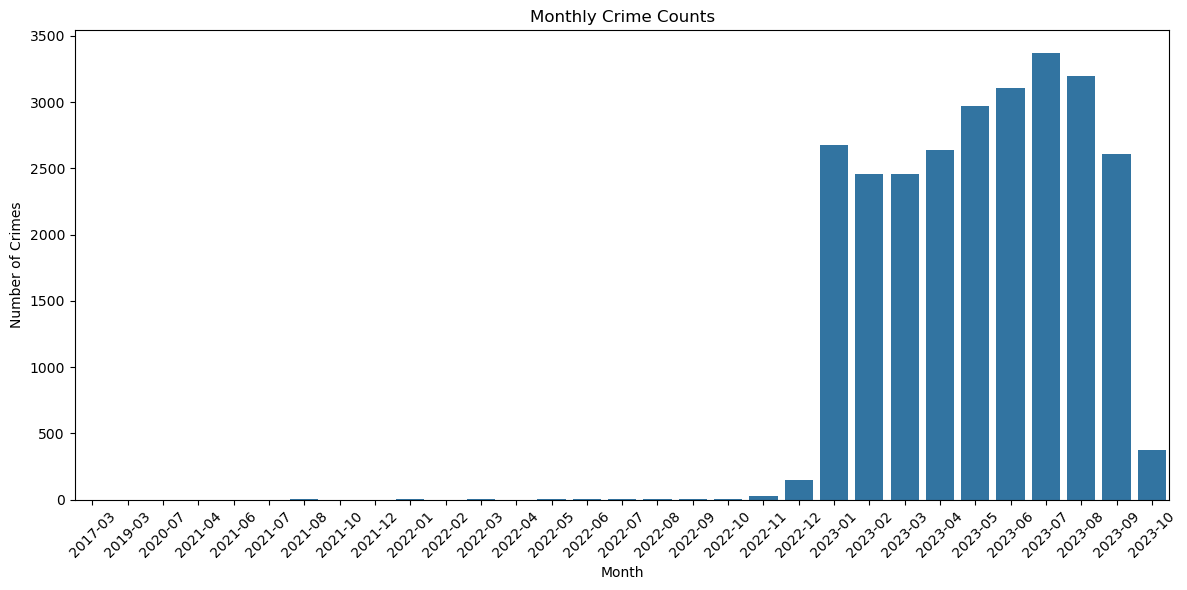

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_counts.index.astype(str), y=monthly_counts.values)
plt.title('Monthly Crime Counts')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

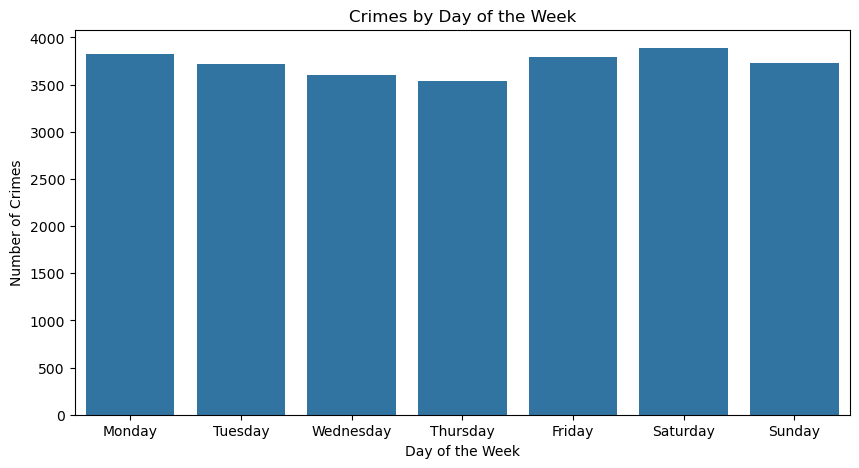

In [17]:
df['day_of_week'] = df['start_date'].dt.dayofweek
weekday_counts = df['day_of_week'].value_counts().sort_index()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,5))
sns.barplot(x=days, y=weekday_counts)
plt.title('Crimes by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Crimes')
plt.show()

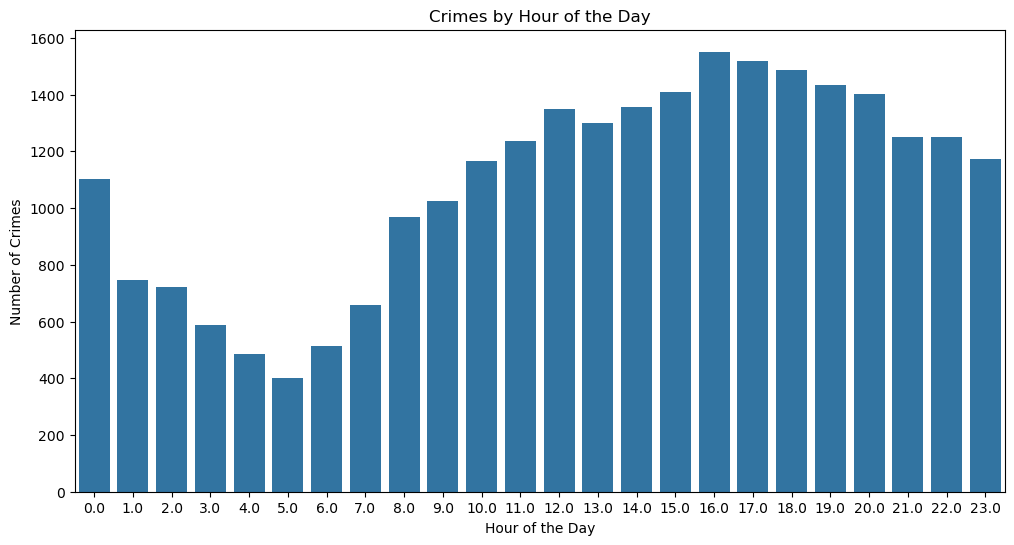

In [18]:
df['hour'] = df['start_date'].dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=hourly_counts.index, y=hourly_counts)
plt.title('Crimes by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Crimes')
plt.xticks(ticks=range(24), rotation=0)
plt.show()